# Day 3 Assignment: House Price Prediction Using Regression

##Name: Divyashree R

**Project Objective:** To build a regression model that accurately predicts the sale price of houses based on a large number of features. This project starts with EDA and moves to preprocessing, feature engineering, model training and evaluation.

Google Colab Link: https://colab.research.google.com/drive/1UecyjrXO1umLyeeyeUVBlVhkiHHwXfkk?usp=sharing


###1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import xgboost as xgb
import os
sns.set_style('darkgrid')

###2. Install Kaggle API

In [ ]:
!pip install -q kaggle

###3. Upload kaggle.json and Setup Kaggle API

In [ ]:
from google.colab import files
print("Upload your kaggle.json file")
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Upload your kaggle.json file


Saving kaggle.json to kaggle.json


###4. Download and understand dataset

In [ ]:
!kaggle competitions download -c house-prices-advanced-regression-techniques
!unzip -o house-prices-advanced-regression-techniques.zip
print("Dataset downloaded and unzipped.")

  0% 0.00/199k [00:00<?, ?B/s]
100% 199k/199k [00:00<00:00, 394MB/s]
Archive:  house-prices-advanced-regression-techniques.zip
  inflating: data_description.txt    
  inflating: sample_submission.csv   
  inflating: test.csv                
  inflating: train.csv               
Dataset downloaded and unzipped.


In [ ]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (1460, 81)
Test shape: (1459, 80)


In [ ]:
train_df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
train_df.tail()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [ ]:
train_df.set_index('Id', inplace=True)
test_df.set_index('Id', inplace=True)

In [ ]:
train_df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


###5. EDA on Target Variable (SalePrice)

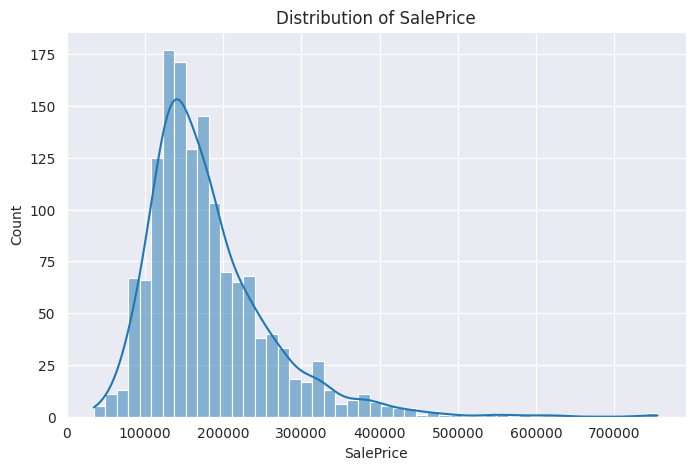

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(train_df["SalePrice"], kde=True)

plt.title("Distribution of SalePrice")
plt.xlabel("SalePrice")
plt.ylabel("Count")

plt.show()

####a) Calculate Skewness

In [ ]:
skewness = train_df["SalePrice"].skew()
print("Skewness of SalePrice:", skewness)

Skewness of SalePrice: 1.8828757597682129


####b) Apply Log Transformations

In [ ]:
train_df["SalePrice"] = np.log1p(train_df["SalePrice"])

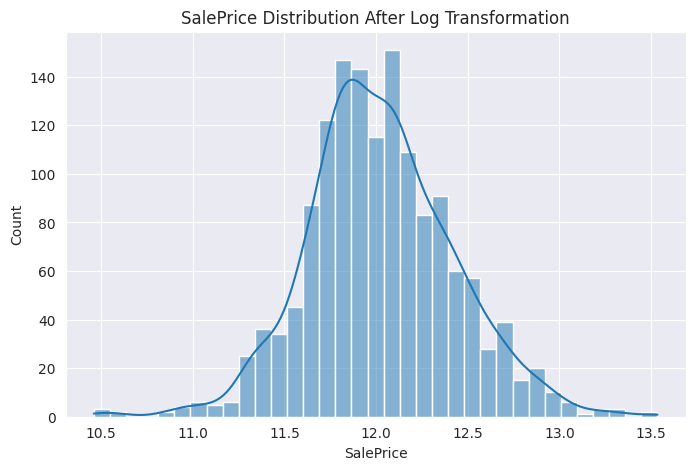

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(train_df["SalePrice"], kde=True)

plt.title("SalePrice Distribution After Log Transformation")

plt.show()

In [ ]:
print(f"Skewness of Log-Transformed SalePrice: {train_df['SalePrice'].skew()}")

Skewness of Log-Transformed SalePrice: 0.12134661989685333


###6. EDA on Feature Variables

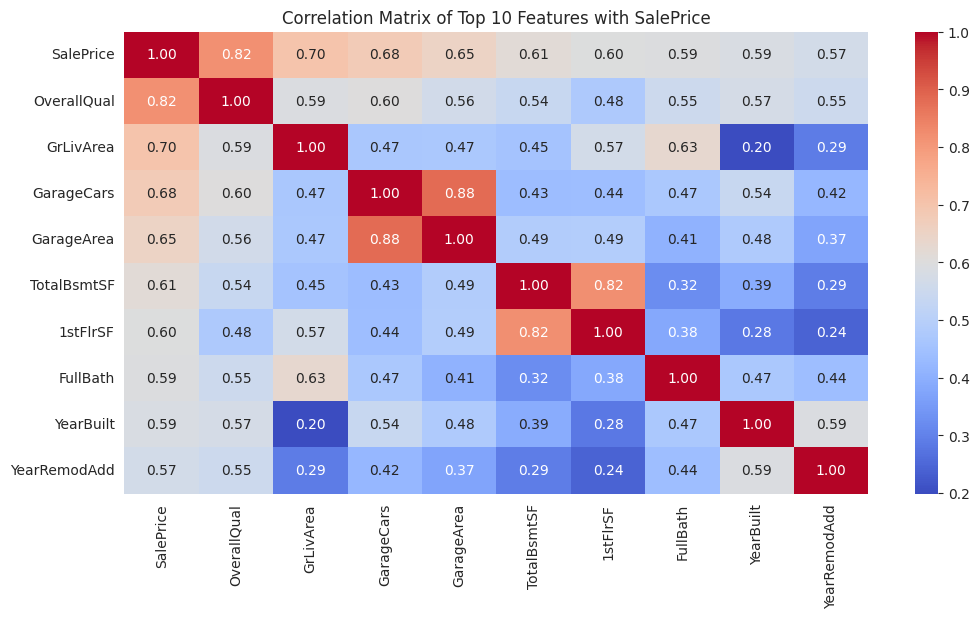

In [ ]:
corrmat = train_df.corr(numeric_only=True)
top_corr_features = corrmat.nlargest(10,'SalePrice')['SalePrice'].index
top_corr_matrix = train_df[top_corr_features].corr()

plt.figure(figsize=(12,6))
sns.heatmap(top_corr_matrix,annot=True,cmap='coolwarm',fmt='.2f')
plt.title('Correlation Matrix of Top 10 Features with SalePrice')
plt.show()

###7. Data Preprocessing

In [ ]:
# Combine train and test data for consistent preprocessing
combined = pd.concat((train_df.loc[:,:'SaleCondition'],
                      test_df.loc[:,:'SaleCondition']))

print(f"Combined data shape: {combined.shape}")

Combined data shape: (2919, 79)


###8. Handle missing values

In [ ]:
missing_values = combined.isnull().sum().sort_values(ascending=False)
missing_values.head(20)

,0
PoolQC,2909
MiscFeature,2814
Alley,2721
Fence,2348
MasVnrType,1766
FireplaceQu,1420
LotFrontage,486
GarageCond,159
GarageFinish,159
GarageYrBlt,159


In [ ]:
# Impute numerical features with 0
numerical_cols_to_impute_zero = ['MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'GarageCars', 'GarageArea', 'BsmtFullBath', 'BsmtHalfBath']
for col in numerical_cols_to_impute_zero:
    if col in combined.columns:
        combined[col] = combined[col].fillna(0)

In [ ]:
combined[numerical_cols_to_impute_zero].isna().sum()

,0
MasVnrArea,0
BsmtFinSF1,0
BsmtFinSF2,0
BsmtUnfSF,0
TotalBsmtSF,0
GarageCars,0
GarageArea,0
BsmtFullBath,0
BsmtHalfBath,0


In [ ]:
combined['LotFrontage'].value_counts()

,count
LotFrontage,
60.0,276
80.0,137
70.0,133
50.0,117
75.0,105
...,...
155.0,1
126.0,1
200.0,1


In [ ]:
# Impute LotFrontage with the median of the neighborhood
if 'LotFrontage' in combined.columns and combined['LotFrontage'].isna().any():
    combined['LotFrontage'] = combined.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))

In [ ]:
combined['Alley'].value_counts()

,count
Alley,
Grvl,120
Pave,78


In [ ]:
# Impute categorical features with 'None' (for features where NA means 'no') or mode (for features where NA means missing data)
categorical_cols_to_impute_none = ['Alley', 'Fence', 'MiscFeature', 'PoolQC', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'MasVnrType']
for col in categorical_cols_to_impute_none:
    if col in combined.columns:
        combined[col] = combined[col].fillna('None')

In [ ]:
for col in ['Electrical', 'KitchenQual', 'Exterior1st', 'Exterior2nd', 'SaleType', 'Utilities', 'Functional', 'MSZoning']:
    if col in combined.columns: # Check if column exists after one-hot encoding
        combined[col] = combined[col].fillna(combined[col].mode()[0])

In [ ]:
combined['GarageYrBlt'].value_counts()

,count
GarageYrBlt,
2005.0,142
2006.0,115
2007.0,115
2004.0,99
2003.0,92
...,...
1896.0,1
1895.0,1
2207.0,1


In [ ]:
combined.isna().sum()

,0
MSSubClass,0
MSZoning,0
LotFrontage,0
LotArea,0
Street,0
...,...
MiscVal,0
MoSold,0
YrSold,0
SaleType,0


In [ ]:
if 'GarageYrBlt' in combined.columns:
    combined['GarageYrBlt'] = combined['GarageYrBlt'].fillna(0)

In [ ]:
print("\nMissing values after all imputation:", combined.isna().sum().sum())


Missing values after all imputation: 0


###9. Feature Engineering

In [ ]:
# Create a total square footage feature
combined['TotalSF'] = combined['TotalBsmtSF'] + combined['1stFlrSF'] + combined['2ndFlrSF']

In [ ]:
# Create a total bathrooms feature
combined['TotalBath'] = (
    combined['FullBath'] +
    (0.5 * combined['HalfBath']) +
    combined['BsmtFullBath'] +
    (0.5 * combined['BsmtHalfBath'])
)

In [ ]:
# Create a feature for age of the house at sale
combined['Age'] = combined['YrSold'] - combined['YearBuilt']

###10. Categorical Encoding

In [ ]:
categorical_cols = combined.select_dtypes(include=['object']).columns

In [ ]:
combined = pd.get_dummies(combined, columns=categorical_cols, drop_first=True)

In [ ]:
print("Shape after encoding:", combined.shape)

Shape after encoding: (2919, 262)


In [ ]:
combined.isnull().sum().sum()

np.int64(0)

###11. Model Building & Training

In [ ]:
# Separate the preprocessed data back into training and testing sets
X = combined[:len(train_df)]
y = train_df['SalePrice']
X_test_final = combined[len(train_df):]

In [ ]:
# Split the training data for validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

###12. Feature Scaling

In [ ]:
data = {
    'age': np.random.randint(20, 60, 5),
    'salary': np.random.randint(40000, 120000, 5),
    'experience': np.random.randint(0, 30, 5),
}

# Create the DataFrame
custom_df = pd.DataFrame(data)

# Display the DataFrame
display(custom_df.head())

,age,salary,experience
0,46,61355,28
1,53,110094,28
2,27,41950,19
3,52,114851,0
4,27,116354,2


In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Fit scaler on training data and transform
X_train_scaled = scaler.fit_transform(X_train)

# Use same scaler to transform validation data
X_val_scaled = scaler.transform(X_val)

# Use same scaler to transform test data
X_test_final_scaled = scaler.transform(X_test_final)

In [ ]:
custom_df['salary']/111333

,salary
0,0.551094
1,0.988871
2,0.376798
3,1.031599
4,1.045099


In [ ]:
custom_df['age']/57

,age
0,0.807018
1,0.929825
2,0.473684
3,0.912281
4,0.473684


In [ ]:
X_train

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
Id,,,,,,,,,,,,,,,,,,,,,
255,20,70.0,8400,5,6,1957,1957,0.0,922.0,0.0,...,False,False,False,False,True,False,False,False,True,False
1067,60,59.0,7837,6,7,1993,1994,0.0,0.0,0.0,...,False,False,False,False,True,False,False,False,True,False
639,30,67.0,8777,5,7,1910,1950,0.0,0.0,0.0,...,False,False,False,False,True,False,False,False,True,False
800,50,60.0,7200,5,7,1937,1950,252.0,569.0,0.0,...,False,False,False,False,True,False,False,False,True,False
381,50,50.0,5000,5,6,1924,1950,0.0,218.0,0.0,...,False,False,False,False,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1096,20,78.0,9317,6,5,2006,2006,0.0,24.0,0.0,...,False,False,False,False,True,False,False,False,True,False
1131,50,65.0,7804,4,3,1928,1950,0.0,622.0,0.0,...,False,False,False,False,True,False,False,False,True,False
1295,20,60.0,8172,5,7,1955,1990,0.0,167.0,0.0,...,False,False,False,False,True,False,False,False,True,False


In [ ]:
X_train_scaled

array([[-0.8667643 , -0.01933867, -0.21289571, ..., -0.12510865,
         0.46001984, -0.30263639],
       [ 0.07410996, -0.50039047, -0.26524463, ..., -0.12510865,
         0.46001984, -0.30263639],
       [-0.63154574, -0.15053462, -0.17784146, ..., -0.12510865,
         0.46001984, -0.30263639],
       ...,
       [-0.8667643 , -0.45665849, -0.23409563, ..., -0.12510865,
         0.46001984, -0.30263639],
       [-0.16110861, -0.6753184 , -0.28337613, ..., -0.12510865,
         0.46001984, -0.30263639],
       [ 1.48542135, -0.76278236, -0.65139925, ..., -0.12510865,
         0.46001984, -0.30263639]])

###13. Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_val_scaled)

####13a. Ridge Regression

In [ ]:
from sklearn.linear_model import Ridge, Lasso
ridge = Ridge(alpha=10)

ridge.fit(X_train_scaled, y_train)

y_pred_ridge = ridge.predict(X_val_scaled)

In [ ]:
evaluate_model(y_val, y_pred_ridge, "Ridge Regression")

--- Ridge Regression Performance ---
RMSE: 0.1563
MAE:  0.0970
R-squared: 0.8691



####13b. Lasso Regression

In [ ]:
lasso = Lasso(alpha=0.001)

lasso.fit(X_train_scaled, y_train)

y_pred_lasso = lasso.predict(X_val_scaled)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.833e-02, tolerance: 1.781e-02
  model = cd_fast.enet_coordinate_descent(


In [ ]:
evaluate_model(y_val, y_pred_lasso, "Lasso Regression")

--- Lasso Regression Performance ---
RMSE: 0.1557
MAE:  0.0956
R-squared: 0.8701



###14. XGBoost (Extreme Gradient Boosting)

In [ ]:
xgbr = xgb.XGBRegressor(objective='reg:squarederror',
                        n_estimators=10000,
                        learning_rate=0.05,
                        max_depth=3,
                        min_child_weight=1,
                        subsample=0.8,
                        colsample_bytree=0.8,
                        random_state=42)
xgbr.fit(X_train, y_train)
y_pred_xgb = xgbr.predict(X_val)

###15. Model Evaluation

In [ ]:
def evaluate_model(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"--- {model_name} Performance ---")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"R-squared: {r2:.4f}\n")
evaluate_model(y_val,y_pred_lr,'Linear Regression')
evaluate_model(y_val, y_pred_xgb, "XGBoost")

--- Linear Regression Performance ---
RMSE: 0.1734
MAE:  0.0960
R-squared: 0.8389

--- XGBoost Performance ---
RMSE: 0.1324
MAE:  0.0859
R-squared: 0.9060



In [ ]:
final_predictions_log = xgbr.predict(X_test_final)

#Reverse the log transformation to get the predictions back on the original price scale
final_predictions = np.expm1(final_predictions_log)

# Create the submission DataFrame
submission = pd.DataFrame({'Id': test_df.index, 'SalePrice': final_predictions})

# Save to csv
submission.to_csv('submission.csv', index=False)

submission.head()

,Id,SalePrice
0,1461,124708.789062
1,1462,164473.437500
2,1463,189848.312500
3,1464,196051.765625
4,1465,181740.234375


In [ ]:
submission.shape

(1459, 2)

In [ ]:
submission.columns

Index(['Id', 'SalePrice'], dtype='object')

In [ ]:
submission.head()
submission.tail()

,Id,SalePrice
1454,2915,85373.367188
1455,2916,78044.187500
1456,2917,169909.312500
1457,2918,120716.812500
1458,2919,220128.750000


In [ ]:
submission.isnull().sum()

,0
Id,0
SalePrice,0


### Conclusion

In this project, we built a machine learning pipeline to predict house prices using the **House Prices: Advanced Regression Techniques** dataset. The workflow began with exploratory data analysis (EDA) to understand the dataset structure, distributions, and relationships between features and the target variable **SalePrice**. Skewness in the target variable was addressed using a log transformation to improve model performance.

Next, missing values were handled and new meaningful features such as **Total Square Footage**, **Total Bathrooms**, and **Age of the House** were engineered to better represent property characteristics. Categorical variables were converted into numerical format using **one-hot encoding**, allowing machine learning models to process them effectively.

The dataset was then split into training and validation sets, and **feature scaling** was applied to standardize numerical features for algorithms sensitive to feature magnitude. Two models were trained and evaluated: **Linear Regression** as a baseline model and **XGBoost Regressor** as a more advanced ensemble method.

Model evaluation using metrics such as **RMSE, MAE, and R²** indicated that the **XGBoost model performed better**, capturing complex relationships between features and house prices more effectively than the baseline linear regression model.

Finally, predictions were generated for the test dataset, transformed back from the log scale, and exported as a **submission file** for the Kaggle competition. This project demonstrates a complete machine learning workflow—from data preprocessing and feature engineering to model training, evaluation, and generating real-world predictions.
